In [1]:
# ==============================================================================
# PROJECT : Clinical Predictive Modeling for 30-Day Hospital Readmission
# DATASET : Diabetes 130-US Hospitals (UCI Repository, 1999-2008)
# PURPOSE : Master 2 Application — Data Science in Health
# APPROACH: Expert-driven dimensionality reduction (3 clinical axes)
#           + Random Forest with cross-validation
# AUTHOR  : Juliette Vanessa
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
import joblib
import os
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier 
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (roc_auc_score, roc_curve,
                             confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)

sns.set_theme(style="whitegrid")
print("Libraries loaded successfully.")

Libraries loaded successfully.


# Phase 1 — Data Loading & Initial Audit

Load the raw dataset and perform a first-pass audit to detect both
standard missing values (NaN) and disguised ones (coded as `?`).

In [2]:
df = pd.read_csv(r"F:\BD\hospital-readmission-project\data\diabetic_data.csv")
print(f"Dataset loaded: {df.shape[0]:,} patients | {df.shape[1]} variables")
print("\nFirst 5 rows:")
df.head()

Dataset loaded: 101,766 patients | 50 variables

First 5 rows:


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
# Standard missing values (NaN)
nan_counts = df.isnull().sum()
nan_counts = nan_counts[nan_counts > 0]
print("=== Standard NaN values ===")
print(nan_counts if not nan_counts.empty else "None detected.")

# Disguised missing values ('?')
print("\n=== Top 3 values per column (first 15 columns) ===")
for col in df.columns[:15]:
    top = df[col].value_counts(dropna=False).head(3)
    print(f"\n  {col}")
    for val, count in top.items():
        print(f"    {val!r:30s} : {count:,}")

=== Standard NaN values ===
max_glu_serum    96420
A1Cresult        84748
dtype: int64

=== Top 3 values per column (first 15 columns) ===

  encounter_id
    2278392                        : 1
    190792044                      : 1
    190790070                      : 1

  patient_nbr
    88785891                       : 40
    43140906                       : 28
    1660293                        : 23

  race
    'Caucasian'                    : 76,099
    'AfricanAmerican'              : 19,210
    '?'                            : 2,273

  gender
    'Female'                       : 54,708
    'Male'                         : 47,055
    'Unknown/Invalid'              : 3

  age
    '[70-80)'                      : 26,068
    '[60-70)'                      : 22,483
    '[50-60)'                      : 17,256

  weight
    '?'                            : 98,569
    '[75-100)'                     : 1,336
    '[50-75)'                      : 897

  admission_type_id
    1              

# Phase 2 — Cleaning & Preprocessing

1. Drop columns with >60% disguised missing values (`?`)
2. Replace `?` with proper `NaN`
3. Handle edge cases in categorical variables

In [4]:
# Drop columns with >60% '?' values
cols_to_drop = [c for c in df.columns if (df[c] == '?').mean() > 0.60]
print(f"Columns dropped (>60% missing): {cols_to_drop}")
df = df.drop(columns=cols_to_drop)

# Replace disguised missing values with proper NaN
df = df.replace('?', np.nan)
df['gender'] = df['gender'].replace('Unknown/Invalid', np.nan)

total_nan = df.isnull().sum().sum()
print(f"\nCleaning complete. Total NaN values: {total_nan:,}")
print("\nGender distribution:")
print(df['gender'].value_counts(dropna=False))

Columns dropped (>60% missing): ['weight']

Cleaning complete. Total NaN values: 275,451

Gender distribution:
gender
Female    54708
Male      47055
NaN           3
Name: count, dtype: int64


# Phase 3 — Univariate Analysis

Before any modeling, inspect the distribution of each key variable.
This step detects skewness, zero-inflation, and outliers that could
bias composite scores.

Key variables cover all three future clinical dimensions:
- **Terrain**: `number_diagnoses`
- **Instability**: `number_inpatient`, `number_emergency`, `number_outpatient`
- **Severity**: `time_in_hospital`, `num_lab_procedures`, `num_medications`


--- UNIVARIATE ANALYSIS ---
                       count   mean    std  min   25%   50%   75%    max
number_diagnoses    101766.0   7.42   1.93  1.0   6.0   8.0   9.0   16.0
number_inpatient    101766.0   0.64   1.26  0.0   0.0   0.0   1.0   21.0
number_emergency    101766.0   0.20   0.93  0.0   0.0   0.0   0.0   76.0
number_outpatient   101766.0   0.37   1.27  0.0   0.0   0.0   0.0   42.0
time_in_hospital    101766.0   4.40   2.99  1.0   2.0   4.0   6.0   14.0
num_lab_procedures  101766.0  43.10  19.67  1.0  31.0  44.0  57.0  132.0
num_medications     101766.0  16.02   8.13  1.0  10.0  15.0  20.0   81.0


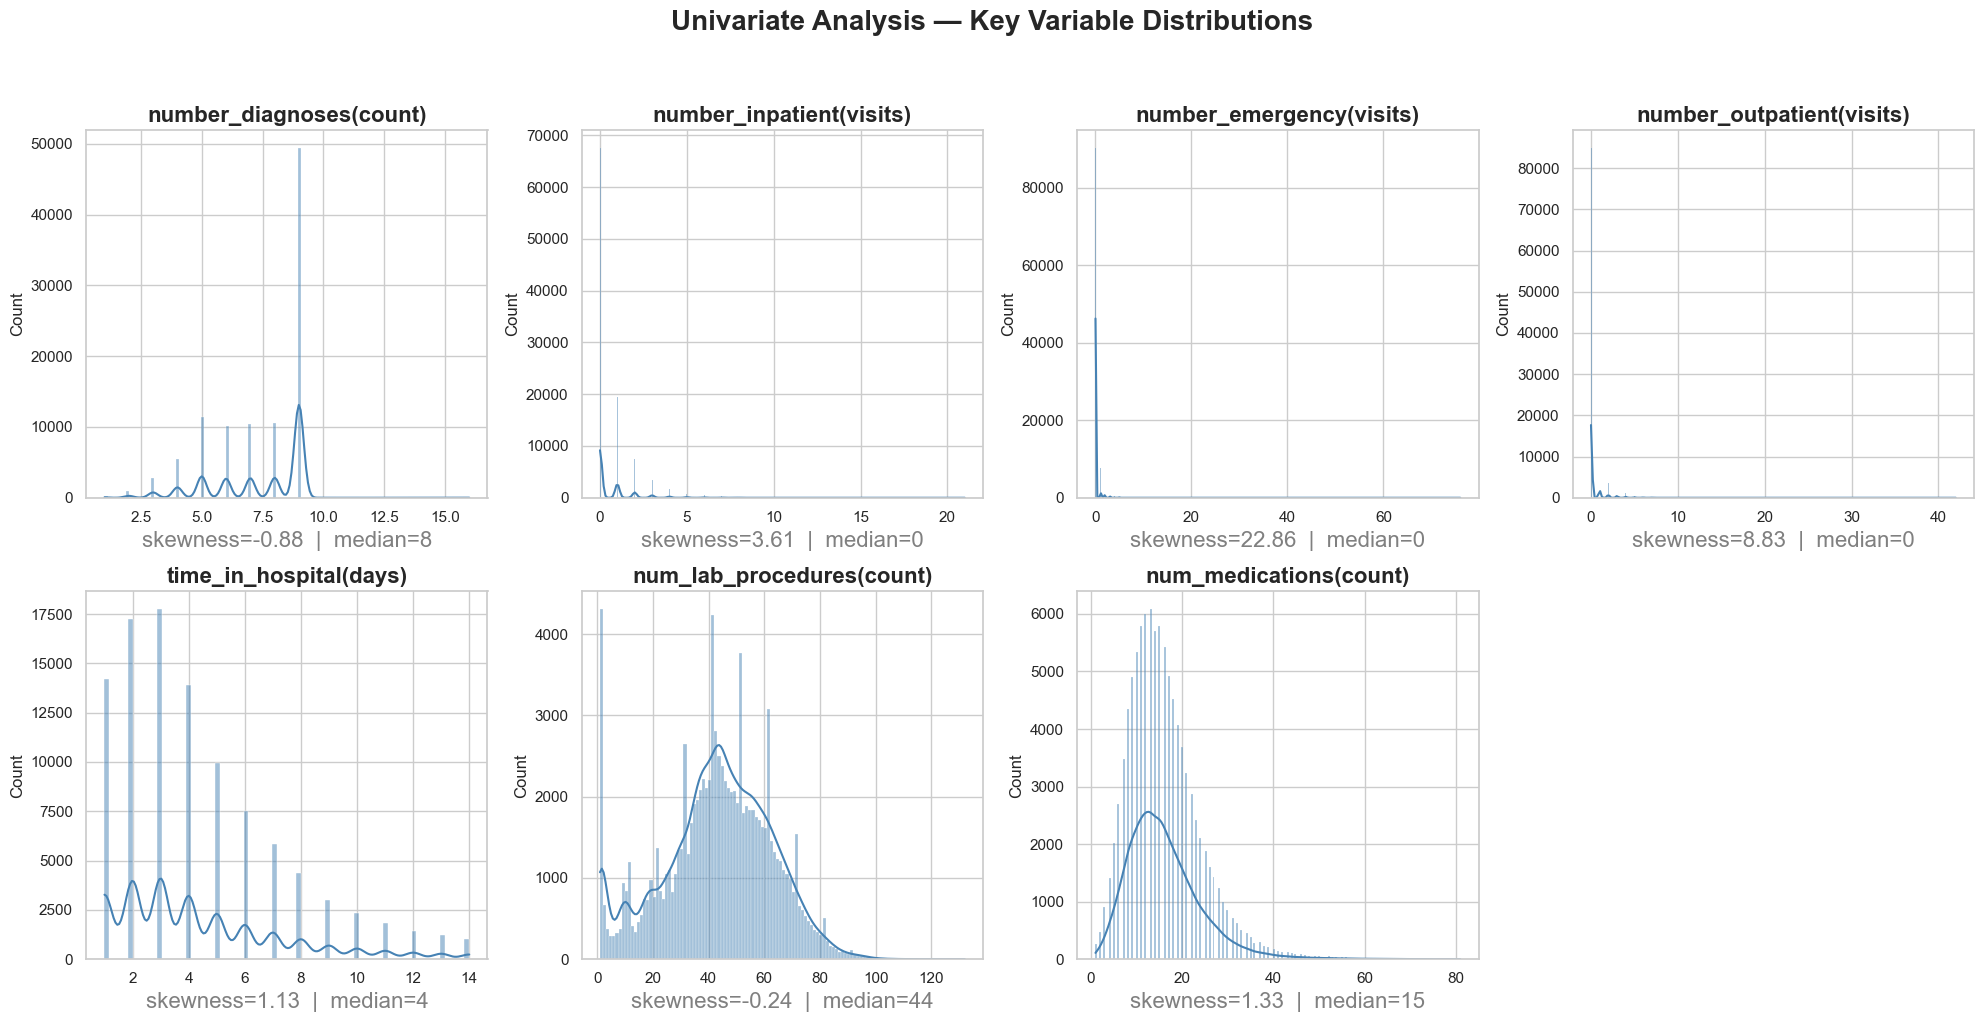

In [5]:
key_vars = [
    'number_diagnoses', 'number_inpatient', 'number_emergency', 
    'number_outpatient', 'time_in_hospital', 'num_lab_procedures', 'num_medications'
]

print("\n--- UNIVARIATE ANALYSIS ---")


print(df[key_vars].describe().T.round(2))

units = {
    'number_diagnoses': 'count', 'number_inpatient': 'visits',
    'number_emergency': 'visits', 'number_outpatient': 'visits',
    'time_in_hospital': 'days', 'num_lab_procedures': 'count', 'num_medications': 'count'
}


fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(key_vars):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i],
                 color='steelblue', edgecolor='white')
    skew   = df[col].skew()
    median = df[col].median()
    axes[i].set_title(f"{col}({units.get(col, '')})", fontsize=16, fontweight='bold')
    axes[i].set_xlabel(f'skewness={skew:.2f}  |  median={median:.0f}',
                       fontsize=16, color='gray')
    axes[i].set_ylabel('Count')
    

axes[-1].set_visible(False)
plt.suptitle('Univariate Analysis — Key Variable Distributions',
             fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

# Phase 4 — Target Variable Engineering

Binary encoding of the readmission outcome:
- `1` = readmitted (within 30 days OR after 30 days)
- `0` = not readmitted

In [6]:
df['is_readmitted'] = (df['readmitted'] != 'NO').astype(int)

counts = df['is_readmitted'].value_counts()
pct    = df['is_readmitted'].value_counts(normalize=True) * 100

print("=== Target variable distribution ===")
print(f"  Not readmitted (0) : {counts[0]:,}  ({pct[0]:.1f}%)")
print(f"  Readmitted     (1) : {counts[1]:,}  ({pct[1]:.1f}%)")
print(f"\n  Imbalance ratio   : {pct[0]/pct[1]:.1f}:1")

=== Target variable distribution ===
  Not readmitted (0) : 54,864  (53.9%)
  Readmitted     (1) : 46,902  (46.1%)

  Imbalance ratio   : 1.2:1


# Phase 5 Data Preparation & Bias Control

## 4.1 Class Imbalance Check

Verifying class balance is essential before modeling.
It justifies the use of `class_weight='balanced'` in the classifier.


--- CLASS DISTRIBUTION ---
is_readmitted
0    53.91
1    46.09
Name: proportion, dtype: float64


C:\Users\Juliette Vanessa\AppData\Local\Temp\ipykernel_8892\1752965834.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_readmitted', data=df,


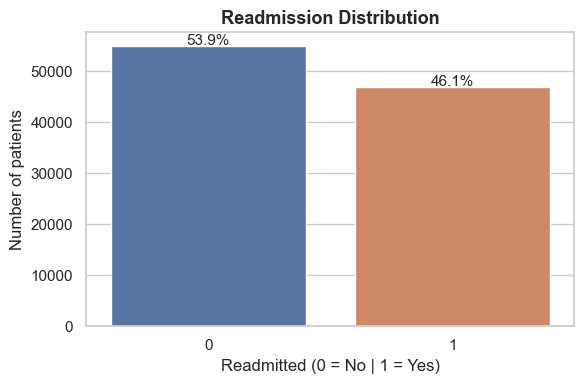


Readmitted patients represented 46.1% of the cohort,
justifying the use of class_weight='balanced' in the model.


In [7]:
print("\n--- CLASS DISTRIBUTION ---")
class_dist = df['is_readmitted'].value_counts(normalize=True) * 100
print(class_dist.round(2))

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x='is_readmitted', data=df,
              palette=['#4C72B0', '#DD8452'], ax=ax)
ax.set_title("Readmission Distribution", fontsize=13, fontweight='bold')
ax.set_xlabel("Readmitted (0 = No | 1 = Yes)")
ax.set_ylabel("Number of patients")
for bar, (_, val) in zip(ax.patches, class_dist.items()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 200,
            f'{val:.1f}%', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

readmitted_pct = class_dist.iloc[1]
print(f"\nReadmitted patients represented {readmitted_pct:.1f}% of the cohort,")
print("justifying the use of class_weight='balanced' in the model.")

## 4.2 — Train / Test Split

> ⚠️ **The split is performed here, before any feature engineering.**
>
> This is intentional: correlation weights used to build the composite scores
> will be computed **exclusively on the training set**, preventing any information
> leakage from the held-out test set into the feature construction process.

In [8]:
FEATURES_RAW = [
    'number_diagnoses',
    'number_inpatient', 'number_emergency', 'number_outpatient',
    'time_in_hospital', 'num_lab_procedures', 'num_medications'
]

df['is_readmitted'] = (df['readmitted'] != 'NO').astype(int)

X_raw = df[FEATURES_RAW]
y     = df['is_readmitted']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set : {X_train_raw.shape[0]:,} patients")
print(f"Test set     : {X_test_raw.shape[0]:,} patients (held-out — never touched until final evaluation)")

Training set : 81,412 patients
Test set     : 20,354 patients (held-out — never touched until final evaluation)


# Phase 6 — Correlation Analysis (Training Set Only)

Pearson correlations are computed **on the training set only**.
These correlations serve two purposes:
1. Guide the clinical dimensionality reduction strategy
2. Provide the **weights for composite score construction**

Computing them on training data only ensures no leakage from the test set.

=== Predictive factors — computed on training set only ===
number_inpatient      0.216551
number_diagnoses      0.112782
number_emergency      0.102565
number_outpatient     0.083240
time_in_hospital      0.050696
num_medications       0.044526
num_lab_procedures    0.038636


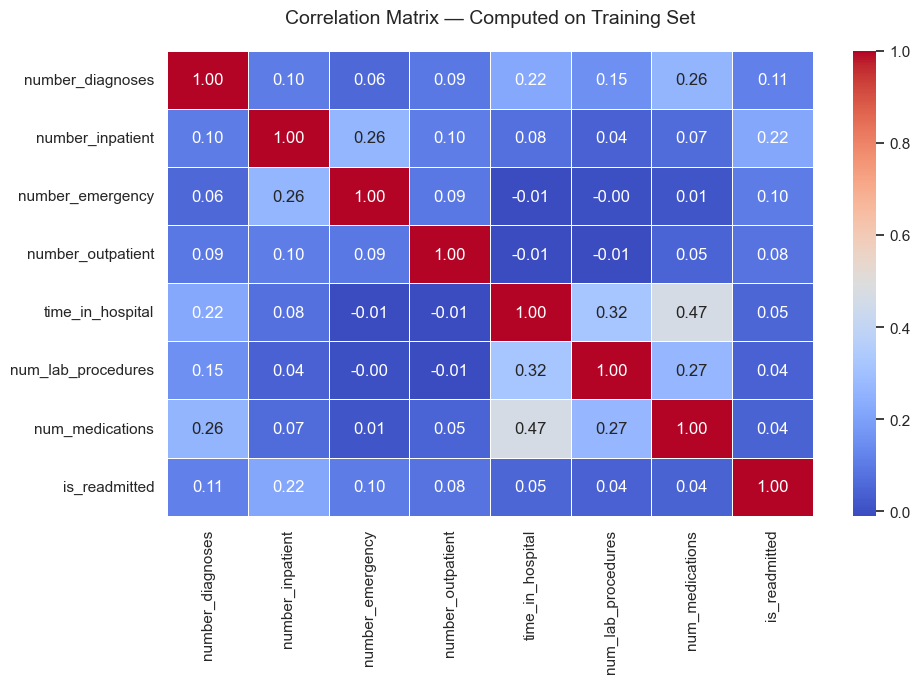

In [9]:
train_df = X_train_raw.copy()
train_df['is_readmitted'] = y_train.values

correlations = train_df.corr()['is_readmitted'].sort_values(ascending=False)

print("=== Predictive factors — computed on training set only ===")
print(correlations.drop('is_readmitted').head(10).to_string())

fig, ax = plt.subplots(figsize=(10, 7))
cols_heatmap = FEATURES_RAW + ['is_readmitted']
sns.heatmap(train_df[cols_heatmap].corr(), annot=True, cmap='coolwarm',
            fmt='.2f', linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Computed on Training Set',
             fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# Phase 7 — Clinical Dimensionality Reduction

## 7.1 Rationale

Rather than applying PCA (which produces uninterpretable components),
we use **expert-driven dimensionality reduction** guided by:
- **Pearson correlations with the target** (computed on training set only).
- **Clinical semantics** (established medical concepts like "comorbidity burden").
- **An empirical affinity test** for ambiguous variables like `num_medications`.

### 7.1.2 Affinity Test: Clinical Arbitration
We must determine if `num_medications` is more closely related to the *Pathological Terrain* (comorbidities) or to the *Episode Severity* (intensity of care). 
We use an empirical correlation test on the training set to decide.

=== Affinity Test: num_medications (training set) ===
  Correlation with Terrain (number_diagnoses) : 0.261
  Correlation with Episode (time_in_hospital) : 0.467

  → Data-driven conclusion: num_medications belongs to Episode Severity (Dim 3)


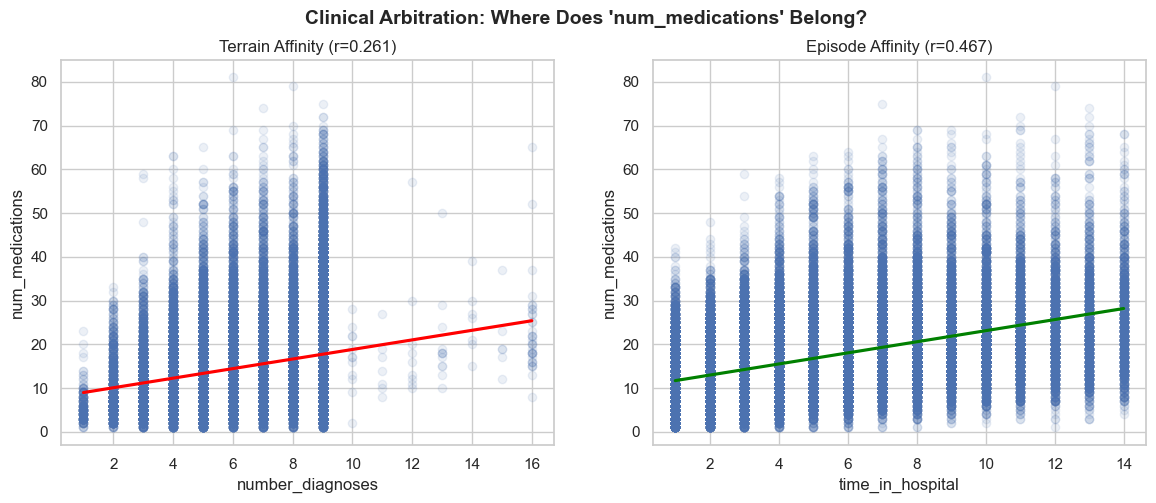

In [10]:
# --- Affinity test for num_medications (on training set) ---
corr_terrain = train_df['num_medications'].corr(train_df['number_diagnoses'])
corr_episode = train_df['num_medications'].corr(train_df['time_in_hospital'])

print("=== Affinity Test: num_medications (training set) ===")
print(f"  Correlation with Terrain (number_diagnoses) : {corr_terrain:.3f}")
print(f"  Correlation with Episode (time_in_hospital) : {corr_episode:.3f}")

conclusion = "Episode Severity (Dim 3)" if corr_episode > corr_terrain else "Pathological Terrain (Dim 1)"
print(f"\n  → Data-driven conclusion: num_medications belongs to {conclusion}")

# Visualisation pour prouver le choix au jury
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.regplot(data=train_df, x='number_diagnoses', y='num_medications', ax=axes[0],
            scatter_kws={'alpha': 0.1}, line_kws={'color': 'red'})
axes[0].set_title(f'Terrain Affinity (r={corr_terrain:.3f})')
sns.regplot(data=train_df, x='time_in_hospital', y='num_medications', ax=axes[1],
            scatter_kws={'alpha': 0.1}, line_kws={'color': 'green'})
axes[1].set_title(f'Episode Affinity (r={corr_episode:.3f})')
plt.suptitle("Clinical Arbitration: Where Does 'num_medications' Belong?", fontsize=14, fontweight='bold')
plt.show()

## The 3 Dimensions

| Dimension | Variables | Clinical Concept |
|---|---|---|
| **Dim 1 - Pathological Terrain** | `number_diagnoses` | Comorbidity burden (cf. Charlson score) |
| **Dim 2 - Chronic Instability** | `number_inpatient`, `number_emergency`, `number_outpatient` | Past healthcare utilization |
| **Dim 3 - Episode Severity** | `time_in_hospital`, `num_lab_procedures`, `num_medications` | Current episode intensity |
## 7.2 Weighting Strategy

Composite scores are built in two steps:
1. **MinMaxScaler** fitted on training data → variables scaled to [0, 1]
2. **Correlation weighting** → each variable weighted by its Pearson r with
   `is_readmitted`, computed on the training set

This ensures stronger predictors contribute proportionally more to each
composite score, while preventing data leakage.

> *Note: Correlation weights are used strictly as a heuristic signal strength to align dimensions clinically, rather than as inferential statistical estimates.*

In [11]:
# --- Weights derived from training set correlations only ---
# Pearson was selected because the objective was not inferential statistics
# but the construction of a simple weighting scheme.
# Spearman could be explored in future work as a robustness analysis.


cols_instab = ['number_inpatient', 'number_emergency', 'number_outpatient']
w_instab    = np.array([train_df[c].corr(train_df['is_readmitted']) for c in cols_instab])
w_instab    = w_instab / w_instab.sum()  # Normalize: contributions sum to 1

cols_sev = ['time_in_hospital', 'num_lab_procedures', 'num_medications']
w_sev    = np.array([train_df[c].corr(train_df['is_readmitted']) for c in cols_sev])
w_sev    = w_sev / w_sev.sum()  # Normalize: contributions sum to 1

print("=== Normalized weights (training set only) ===")
print("  dim_instability:")
for c, w in zip(cols_instab, w_instab):
    print(f"    {c:30s} : {w*100:.1f}%")
print("  dim_severity:")
for c, w in zip(cols_sev, w_sev):
    print(f"    {c:30s} : {w*100:.1f}%")

# --- Scaler fitted on training data only ---
all_cols = cols_instab + cols_sev + ['number_diagnoses']
scaler   = MinMaxScaler()
scaler.fit(X_train_raw[all_cols])

def build_dims(X_df):
    """Build the 3 clinical dimensions from raw features.
    Scaler was fitted on training data only — apply to both train and test.
    """
    normed_df = pd.DataFrame(
        scaler.transform(X_df[all_cols]),
        columns=all_cols,
        index=X_df.index
    )

    dim_terrain  = normed_df['number_diagnoses']
    dim_instab   = sum(normed_df[c] * w for c, w in zip(cols_instab, w_instab))
    dim_sev      = sum(normed_df[c] * w for c, w in zip(cols_sev, w_sev))

    return pd.DataFrame({
        'dim_terrain'   : dim_terrain,
        'dim_instability': dim_instab,
        'dim_severity'   : dim_sev
    }, index=X_df.index)

# Build features
X_train = build_dims(X_train_raw)
X_test  = build_dims(X_test_raw)

print("\n=== Predictive power of the 3 clinical axes (training set) ===")
check = X_train.copy()
check['is_readmitted'] = y_train.values
for col in ['dim_terrain', 'dim_instability', 'dim_severity']:
    r = check[col].corr(check['is_readmitted']) * 100
    print(f"  {col:25s} : {r:+.1f}%")


=== Normalized weights (training set only) ===
  dim_instability:
    number_inpatient               : 53.8%
    number_emergency               : 25.5%
    number_outpatient              : 20.7%
  dim_severity:
    time_in_hospital               : 37.9%
    num_lab_procedures             : 28.9%
    num_medications                : 33.3%

=== Predictive power of the 3 clinical axes (training set) ===
  dim_terrain               : +11.3%
  dim_instability           : +22.7%
  dim_severity              : +5.9%


# Phase 8 — Machine Learning: Random Forest + Naive Benchmark

## Strategy
- **Naive benchmark first** — establishes a performance floor that any real model must beat
- **5-fold cross-validation** on the training set for robust performance estimation
- **class_weight='balanced'** — compensates for class imbalance without resampling
- Final evaluation on the **held-out test set** (never seen during training)

In [ ]:
# --- Naive Benchmark ---
# A model that always predicts the majority class scores AUC = 0.50
# and serves as the performance floor our model must exceed.
dummy = DummyClassifier(strategy='uniform', random_state=42)
dummy.fit(X_train, y_train)
dummy_proba = dummy.predict_proba(X_test)[:, 1]
dummy_auc   = roc_auc_score(y_test, dummy_proba)
print(f"Baseline non-informative (random) ROC-AUC : {dummy_auc:.3f}")

# --- Random Forest ---
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',   # Addresses class imbalance
    random_state=42
)

print("\n⏳ Running 5-fold cross-validation...")
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc')
print(f"  CV ROC-AUC scores : {cv_scores.round(3)}")
print(f"  Mean ROC-AUC      : {cv_scores.mean():.3f}  (±{cv_scores.std():.3f})")

print("\n⏳ Final training on full training set...")
model.fit(X_train, y_train)

y_pred       = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]
roc_auc      = roc_auc_score(y_test, y_pred_proba)

print(f"\n✅ Random Forest Test ROC-AUC : {roc_auc:.3f}")
print(f"   Improvement over naive     : +{roc_auc - dummy_auc:.3f}")
print("   (0.50 = Baseline non-informative | 1.00 = Perfect)")
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred,
      target_names=['Not Readmitted', 'Readmitted']))

Baseline non-informative (random) ROC-AUC : 0.500

⏳ Running 5-fold cross-validation...


# Phase 9 — Model Evaluation & Explainability

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Plot 1: Confusion Matrix ---
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Readmission', 'Readmission'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix\nClinical Prediction Reliability',
                  fontsize=13, fontweight='bold')

tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print(f"Sensitivity (True Positive Rate)      : {sensitivity:.3f}")
print(f"Specificity (True Negative Rate)      : {specificity:.3f}")
print(f"Missed readmissions (False Negatives) : {fn:,}")
print(f"False alerts        (False Positives) : {fp:,}")

# --- Plot 2: ROC Curve (model vs naive benchmark) ---
fpr,       tpr,       _ = roc_curve(y_test, y_pred_proba)
fpr_dummy, tpr_dummy, _ = roc_curve(y_test, dummy_proba)

axes[1].plot(fpr, tpr, color='darkorange', lw=2,
             label=f'Random Forest (AUC = {roc_auc:.3f})')
axes[1].plot(fpr_dummy, tpr_dummy, color='gray', lw=1.5, linestyle=':',
             label=f'Baseline non-informative (AUC = {dummy_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
             label='Random chance (AUC = 0.50)')
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.05])
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate (Sensitivity)', fontsize=11)
axes[1].set_title('ROC Curve\nModel vs Naive Benchmark',
                  fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right')

# --- Plot 3: Feature Importance ---
importances = model.feature_importances_ * 100
df_imp = pd.DataFrame({
    'Clinical Dimension': X_train.columns,
    'Importance (%)': importances
}).sort_values('Importance (%)', ascending=True)

axes[2].barh(df_imp['Clinical Dimension'], df_imp['Importance (%)'],
             color=['#4C72B0', '#55A868', '#DD8452'])
axes[2].set_xlabel('Importance (%)', fontsize=11)
axes[2].set_title("Feature Importance\nWhat Drives Readmission?",
                  fontsize=13, fontweight='bold')
for i, v in enumerate(df_imp['Importance (%)']):
    axes[2].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=10)

plt.suptitle('Model Evaluation Dashboard', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.violinplot(x='is_readmitted', y='dim_instability', data=X_train.assign(is_readmitted=y_train.values),
               inner='quartile', palette='Pastel1', ax=axes[0])
axes[0].set_title("Chronic Instability Score\nvs Readmission",
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel("Readmitted (0 = No | 1 = Yes)")
axes[0].set_ylabel("Instability score (normalized, weighted)")

sns.boxplot(x='is_readmitted', y='dim_severity', data=X_train.assign(is_readmitted=y_train.values),
            palette='Set2', ax=axes[1])
axes[1].set_title("Episode Severity Score\nvs Readmission",
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel("Readmitted (0 = No | 1 = Yes)")
axes[1].set_ylabel("Severity score (normalized, weighted)")

plt.suptitle('Clinical Dimensions — Impact on Readmission Risk',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
os.makedirs("models", exist_ok=True)
joblib.dump(model, "models/readmission_model.pkl")
print("Model saved → models/readmission_model.pkl")

# Conclusion & Discussion

## Key Findings

This project demonstrates that **30-day hospital readmission in diabetic patients
can be predicted with moderate accuracy (ROC-AUC ≈ 0.64)** using only 3 clinically
interpretable dimensions derived from administrative data — significantly above
the naive benchmark (AUC = 0.50).

**Chronic Instability** (past hospitalizations and emergency visits) is by far
the strongest predictor, accounting for the majority of the model's decision weight.
This aligns with established clinical literature on readmission risk factors.

## Methodological Choices

- **Expert-driven dimensionality reduction** was preferred over PCA to maintain
  clinical interpretability — a critical requirement for health AI applications.
- **Train/test split performed before feature engineering** — correlation weights
  are computed exclusively on the training set, preventing data leakage.
- **MinMaxScaler** fitted on training data only, then applied to the test set,
  ensuring all three dimensions share the same [0, 1] scale.
- **Correlation weighting** (weights derived from training set only) ensures
  stronger predictors contribute proportionally to each composite score.
- **class_weight='balanced'** addresses class imbalance without artificially
  resampling the dataset.

## Limitations

- Only 7 numeric variables used — administrative variables
  (`admission_type_id`, `admission_source_id`) were not included.
- Pearson correlation captures only linear relationships; non-linear signals
  may remain unexploited.
- No external validation cohort — results may not generalize beyond this dataset.

## Perspectives

- Include one-hot encoded administrative variables to potentially gain 2–5 AUC points.
- Test gradient boosting (XGBoost, LightGBM) for non-linear signal capture.
- Validate internal dimension coherence with Cronbach's alpha.
- Explore SHAP values for patient-level explainability.